In [39]:
import pandas as pd
import nfl_data_py as nfl
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import accuracy_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
years = [2022, 2023, 2024]
pbp = nfl.import_pbp_data(years=years, downcast=True)
season = nfl.import_seasonal_data(years=years, s_type = 'REG')
weekly = nfl.import_weekly_data(years=years)

print('Play by Play Shape and Sample', pbp.shape, list())
print('Season sample:')
print(season.head(3))
print('Weekly sample:')
print(weekly.head(3))

top_pass_2024 = (
    weekly.query("season == 2024 and season_type == 'REG' and position == 'QB'")
    .groupby(['player_id', 'player_display_name'], as_index=False)['passing_yards']
    .sum()
    .sort_values('passing_yards', ascending=False)
)

top_pass_2024.head()



2022 done.
2023 done.
2024 done.
Downcasting floats.
Downcasting floats.
Play by Play Shape and Sample (148591, 397) []
Season sample:
    player_id  season season_type  completions  attempts  passing_yards  \
0  00-0019596    2022         REG          490       733         4694.0   
1  00-0022824    2022         REG            1         1            4.0   
2  00-0023459    2022         REG          350       542         3695.0   

   passing_tds  interceptions  sacks  sack_yards  ...  yac_sh    wopr_y  \
0           25            9.0   22.0       160.0  ...     0.0  0.004477   
1            0            0.0    0.0         0.0  ...     0.0  0.000000   
2           26           12.0   32.0       258.0  ...     0.0  0.000000   

   ry_sh  rtd_sh  rfd_sh  rtdfd_sh  dom  w8dom  yptmpa    ppr_sh  
0    0.0     0.0     0.0       0.0  0.0    0.0     0.0  0.175012  
1    0.0     NaN     0.0       0.0  NaN    NaN     0.0  0.002352  
2    0.0     0.0     0.0       0.0  0.0    0.0     0.0  0.1665

,player_id,player_display_name,passing_yards
44,00-0036442,Joe Burrow,4918.0
17,00-0033106,Jared Goff,4629.0
30,00-0034855,Baker Mayfield,4500.0
8,00-0030565,Geno Smith,4320.0
32,00-0034869,Sam Darnold,4319.0


In [18]:
# Select only the relevant columns
columns = ['passer_player_name', 'posteam', 'defteam', 'season', 'week', 'home_team', 'away_team', 'play_type', 'air_yards', 
           'yards_after_catch', 'epa', 'complete_pass', 'incomplete_pass', 'interception', 'qb_hit', 'sack', 'pass_touchdown',
           'passing_yards', 'cpoe', 'roof', 'surface']

# Loading in the NFL pbp data
data = nfl.import_pbp_data(range(2001,2024), columns)

# nfl-data-py still loads other columns, so we again need to set our data equal to only the columns we want
data = data[columns]

# Drop all rows that are not a pass
data = data[data['play_type'] == 'pass']

# Drop the play type column
passer_data = data.drop(columns=['play_type'])

2001 done.
2002 done.
2003 done.
2004 done.
2005 done.
2006 done.
2007 done.
2008 done.
2009 done.
2010 done.
2011 done.
2012 done.
2013 done.
2014 done.
2015 done.
'game_id'
Data not available for 2016
'game_id'
Data not available for 2017
'game_id'
Data not available for 2018
'game_id'
Data not available for 2019
'game_id'
Data not available for 2020
'game_id'
Data not available for 2021
'game_id'
Data not available for 2022
'game_id'
Data not available for 2023
Downcasting floats.


In [19]:
# Group the data together by passer, week, season and aggregate
passer_df = passer_data.groupby(['passer_player_name', 'week', 'season'], as_index=False).agg(
    {'posteam' : 'first',
     'defteam' : 'first',
     'home_team' : 'first',
     'away_team' : 'first',
     'air_yards' : 'sum',
     'yards_after_catch' : 'sum',
     'epa' : 'sum',
     'complete_pass' : 'sum',
     'incomplete_pass' : 'sum',
     'interception' : 'sum',
     'qb_hit' : 'sum',
     'sack' : 'sum',
     'pass_touchdown' : 'sum',
     'passing_yards' : 'sum',
     'cpoe' : 'mean',
     'roof' : 'first',
     'surface' : 'first'
     }
)

# Create a new column that is completion percentage
passer_df['completion_percentage'] = passer_df['complete_pass'] / (passer_df['complete_pass'] + passer_df['incomplete_pass'])

# Create a new column that is the number of pass attempts
passer_df['pass_attempts'] = passer_df['complete_pass'] + passer_df['incomplete_pass']

# Drop the complete_pass and incomplete_pass columns
passer_df = passer_df.drop(columns=['complete_pass', 'incomplete_pass'])

# Create a new column that equals 1 if the passer is the home team and 0 if the passer is the away team
passer_df['home_flag'] = passer_df['home_team'] == passer_df['posteam']

# Drop the home_team and away_team columns
passer_df = passer_df.drop(columns=['home_team', 'away_team'])

# Reorder the columns
passer_df = passer_df[['passer_player_name', 'posteam', 'defteam', 'season', 'week', 'passing_yards', 'home_flag', 'completion_percentage', 'pass_attempts',
                       'air_yards',  'yards_after_catch', 'epa', 'interception', 'qb_hit', 'sack', 'pass_touchdown', 
                        'cpoe', 'roof', 'surface']]

In [20]:
# Calculate the exponentially weighted moving average for each feature
passer_df['completion_percentage_ewma'] = passer_df.groupby('passer_player_name')['completion_percentage']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['pass_attempts_ewma'] = passer_df.groupby('passer_player_name')['pass_attempts']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['air_yards_ewma'] = passer_df.groupby('passer_player_name')['air_yards']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['yards_after_catch_ewma'] = passer_df.groupby('passer_player_name')['yards_after_catch']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['epa_ewma'] = passer_df.groupby('passer_player_name')['epa']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['interception_ewma'] = passer_df.groupby('passer_player_name')['interception']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['qb_hit_ewma'] = passer_df.groupby('passer_player_name')['qb_hit']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['sack_ewma'] = passer_df.groupby('passer_player_name')['sack']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['pass_touchdown_ewma'] = passer_df.groupby('passer_player_name')['pass_touchdown']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['passing_yards_ewma'] = passer_df.groupby('passer_player_name')['passing_yards']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['cpoe_ewma'] = passer_df.groupby('passer_player_name')['cpoe']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

# Drop the non-ewma columns
passer_df = passer_df.drop(columns=['completion_percentage', 'pass_attempts', 'air_yards', 'yards_after_catch', 'epa', 
                                    'interception', 'qb_hit', 'sack', 'pass_touchdown', 'cpoe'])

In [21]:
# Select only the relevant columns
defense_columns = ['defteam', 'season', 'week', 'home_team', 'away_team', 'play_type', 'air_yards',
                   'yards_after_catch', 'epa', 'complete_pass', 'incomplete_pass', 'interception', 'qb_hit', 'sack', 'pass_touchdown',
                   'passing_yards', 'cpoe', 'roof', 'surface']


# nfl-data-py still loads other columns, so we again need to set our data equal to only the columns we want
defense_data = data[defense_columns]

# Drop the play type column
defense_data = defense_data.drop(columns=['play_type'])

# Group the data together by passer, week, season and aggregate
defense_df = defense_data.groupby(['defteam', 'week', 'season'], as_index=False).agg(
    {'home_team': 'first',
     'away_team': 'first',
     'air_yards': 'sum',
     'yards_after_catch': 'sum',
     'epa': 'sum',
     'complete_pass': 'sum',
     'incomplete_pass': 'sum',
     'interception': 'sum',
     'qb_hit': 'sum',
     'sack': 'sum',
     'pass_touchdown': 'sum',
     'passing_yards': 'sum',
     'cpoe': 'mean',
     'roof': 'first',
     'surface': 'first'
     }
)

# Create a new column that is completion percentage
defense_df['completion_percentage'] = defense_df['complete_pass'] / (defense_df['complete_pass'] + defense_df['incomplete_pass'])

# Create a new column that is the number of pass attempts
defense_df['pass_attempts'] = defense_df['complete_pass'] + defense_df['incomplete_pass']

# Drop the complete_pass and incomplete_pass columns
defense_df = defense_df.drop(columns=['complete_pass', 'incomplete_pass'])

# Create a new column that equals 1 if the defense is the home team and 0 if the defense is the away team
defense_df['home_flag'] = defense_df['home_team'] == defense_df['defteam']

# Drop the home_team and away_team columns
defense_df = defense_df.drop(columns=['home_team', 'away_team'])

# Reorder the columns
defense_df = defense_df[['defteam', 'season', 'week', 'home_flag', 'passing_yards', 'completion_percentage', 'pass_attempts',
                       'air_yards',  'yards_after_catch', 'epa', 'interception', 'qb_hit', 'sack', 'pass_touchdown', 
                       'cpoe', 'roof', 'surface']]

In [22]:
# Calculate the exponentially weighted moving average for each feature
defense_df['completion_percentage_ewma'] = defense_df.groupby('defteam')['completion_percentage']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['pass_attempts_ewma'] = defense_df.groupby('defteam')['pass_attempts']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['air_yards_ewma'] = defense_df.groupby('defteam')['air_yards']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['yards_after_catch_ewma'] = defense_df.groupby('defteam')['yards_after_catch']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['epa_ewma'] = defense_df.groupby('defteam')['epa']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['interception_ewma'] = defense_df.groupby('defteam')['interception']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['qb_hit_ewma'] = defense_df.groupby('defteam')['qb_hit']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['sack_ewma'] = defense_df.groupby('defteam')['sack']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['pass_touchdown_ewma'] = defense_df.groupby('defteam')['pass_touchdown']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['passing_yards_ewma'] = defense_df.groupby('defteam')['passing_yards']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['cpoe_ewma'] = defense_df.groupby('defteam')['cpoe']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

# Drop the non-ewma columns
defense_df = defense_df.drop(columns=['passing_yards','completion_percentage', 'pass_attempts', 'air_yards', 'yards_after_catch', 'epa', 
                                    'interception', 'qb_hit', 'sack', 'pass_touchdown', 'cpoe'])

In [23]:
# Merge the defense and passer dataframes together
df = passer_df.merge(defense_df, how='inner', on=['defteam', 'season', 'week', 'roof', 'surface'], suffixes=('_passer', '_defense'))
df = df[df['pass_attempts_ewma_passer'] > 5]

In [24]:
# Get an overview of the data
df.describe().round(2)

,season,week,passing_yards,completion_percentage_ewma_passer,pass_attempts_ewma_passer,air_yards_ewma_passer,yards_after_catch_ewma_passer,epa_ewma_passer,interception_ewma_passer,qb_hit_ewma_passer,...,pass_attempts_ewma_defense,air_yards_ewma_defense,yards_after_catch_ewma_defense,epa_ewma_defense,interception_ewma_defense,qb_hit_ewma_defense,sack_ewma_defense,pass_touchdown_ewma_defense,passing_yards_ewma_defense,cpoe_ewma_defense
count,9052.00,9052.00,9052.00,9052.00,9052.00,9052.00,9052.00,9052.00,9052.00,9052.00,...,9052.00,9052.00,9052.00,9052.00,9052.00,9052.00,9052.00,9052.00,9052.00,8881.00
mean,2007.98,9.61,205.68,0.62,28.42,166.10,61.66,0.35,0.86,2.87,...,32.36,187.23,69.14,0.12,1.00,3.26,2.28,1.40,232.97,0.09
std,4.29,5.26,96.35,0.06,6.55,105.51,40.97,4.89,0.41,1.65,...,2.77,62.15,24.00,3.87,0.35,1.08,0.59,0.38,26.45,3.79
min,2001.00,1.00,-7.00,0.12,5.06,0.00,0.00,-32.48,0.00,0.00,...,16.00,0.00,0.00,-32.48,0.00,0.00,0.00,0.00,34.00,-14.71
25%,2004.00,5.00,146.75,0.59,24.89,75.93,26.62,-2.80,0.59,1.61,...,30.50,143.19,51.69,-2.48,0.74,2.49,1.88,1.14,215.47,-2.37
50%,2008.00,10.00,210.00,0.63,29.47,178.57,64.29,0.18,0.83,2.81,...,32.27,189.40,69.26,0.19,0.97,3.19,2.23,1.38,232.29,0.08
75%,2012.00,14.00,270.00,0.66,32.95,254.19,95.13,3.53,1.09,3.97,...,34.16,232.90,86.57,2.69,1.21,3.99,2.64,1.64,250.53,2.66
max,2015.00,21.00,527.00,1.00,52.00,536.00,202.00,27.84,7.00,11.05,...,47.00,368.47,148.68,18.57,3.00,7.71,7.00,3.55,350.90,22.03


C:\Users\rfo7799\AppData\Local\Temp\ipykernel_30776\1815020281.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  dataset_corr = df.corr()


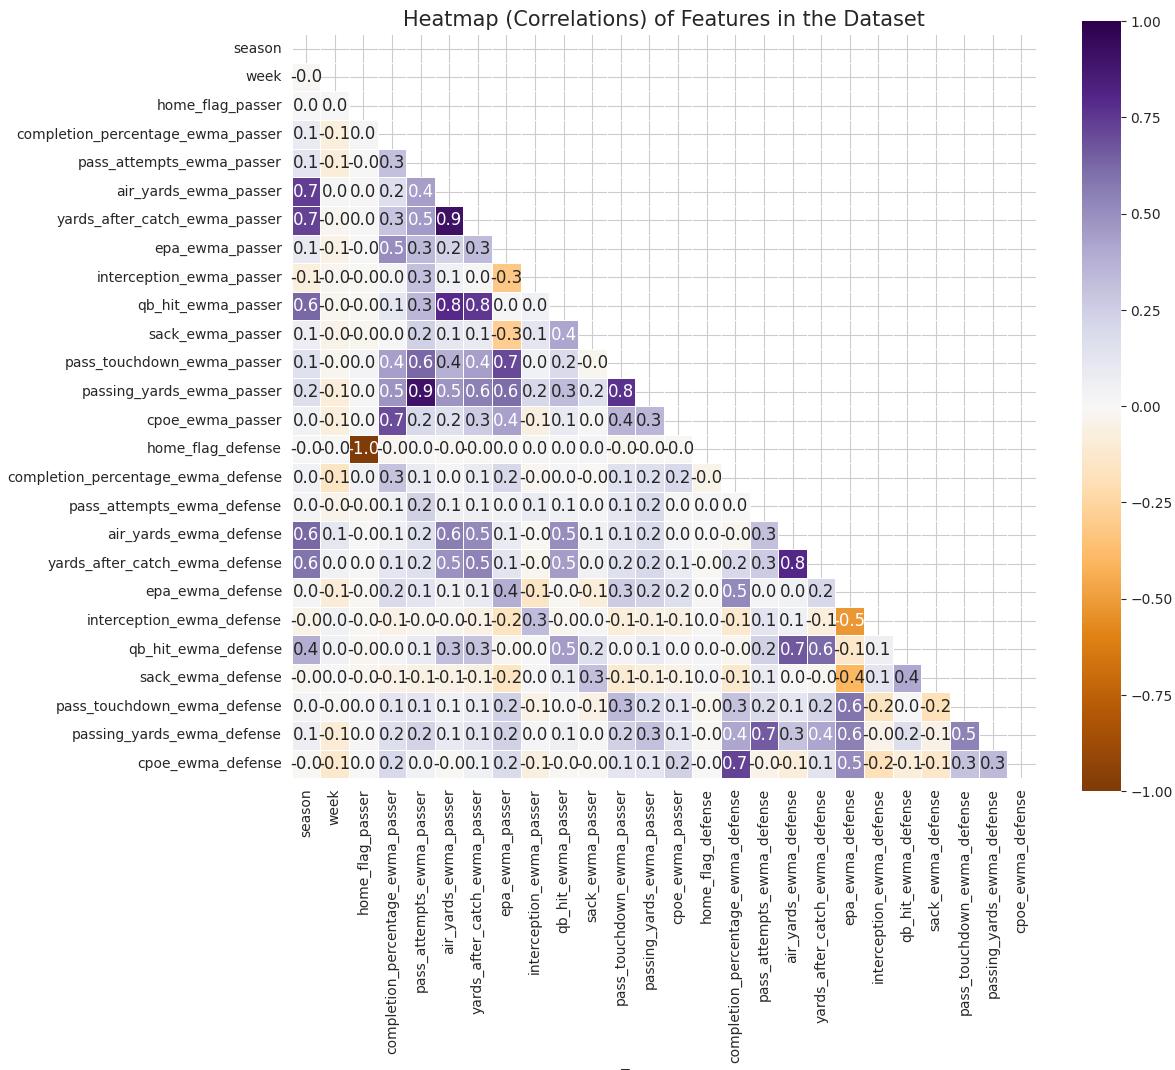

In [29]:
# Create a correlation for the dataset.
dataset_corr = df.corr()

# Drop Agent_ID from correlation dataset.
dataset_corr = dataset_corr.drop(['passing_yards'], axis=1)
dataset_corr = dataset_corr.drop(['passing_yards'], axis=0)

# Create a correlation matrix. Only bottom left corner valued.
mask = np.zeros_like(dataset_corr.round(4))
mask[np.triu_indices_from(mask)] = True

# Generate the corrleation matrix (heatmap) using Seaborn.
with sns.axes_style("whitegrid"):
    f, ax = plt.subplots(figsize=(12, 10))
    ax = sns.heatmap(dataset_corr.round(2), mask=mask, vmax=1, center=0, vmin=-1, square=True,
                     cmap='PuOr', linewidths=.5, annot=True, annot_kws={"size": 12}, fmt='.1f')
    plt.title('Heatmap (Correlations) of Features in the Dataset', fontsize=15)
    plt.xlabel('Features', fontsize=15)
    plt.ylabel('Features', fontsize=15)
plt.show()

In [34]:
df.isnull().sum()
final_df = df.dropna()

In [35]:
len(final_df)

7982

In [38]:
final_df.dtypes

season                                 int64
week                                   int32
passing_yards                        float32
home_flag_passer                        bool
completion_percentage_ewma_passer    float64
                                      ...   
surface_dessograss                     uint8
surface_fieldturf                      uint8
surface_grass                          uint8
surface_matrixturf                     uint8
surface_sportturf                      uint8
Length: 279, dtype: object

In [37]:
# Identify categorical columns to be encoded
categorical_cols = ['passer_player_name', 'posteam', 'defteam', 'roof', 'surface']

# Perform one-hot encoding
final_df = pd.get_dummies(final_df, columns=categorical_cols, drop_first=True)


In [40]:
# Define your features (X) and target (y)
X = final_df.drop('passing_yards', axis=1)  # Features
y = final_df['passing_yards']              # Target

# Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Instantiate the models
models = {
    'RandomForest': RandomForestRegressor(random_state=42),
    'LightGBM': LGBMRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'SVR': SVR(),
}

# Regression models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate metrics
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results[name] = {'RMSE': rmse, 'R-squared': r2, 'MAE': mae}

# Print the comparison results
results_df = pd.DataFrame(results).T.sort_values(by='RMSE')
print(results_df)

# You would choose the best model based on the lowest RMSE
best_model_name = results_df.index[0]
best_model = models[best_model_name]
print(f"\nThe best performing model is: {best_model_name}")

c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001567 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5970
[LightGBM] [Info] Number of data points in the train set: 6385, number of used features: 185
[LightGBM] [Info] Start training from score 210.024589


c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


                   RMSE  R-squared        MAE
LightGBM      66.921358   0.527066  52.120953
RandomForest  67.841579   0.513970  53.138147
XGBoost       69.204285   0.494249  53.933342
SVR           92.318128   0.099995  73.422620

The best performing model is: LightGBM


c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [61]:
# Fine-tuning LightGBM (assuming it was the best model)
lgbm = LGBMRegressor(random_state=42)

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 70],
    'reg_alpha': [0, 0.1, 0.5]
}

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(estimator=lgbm, param_grid=param_grid,
                           cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

# Get the best model and its parameters
tuned_lgbm = grid_search.best_estimator_
best_params = grid_search.best_params_
print(f"\nBest parameters found: {grid_search.best_params_}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003558 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5970
[LightGBM] [Info] Number of data points in the train set: 6385, number of used features: 185
[LightGBM] [Info] Start training from score 210.024589

Best parameters found: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 31, 'reg_alpha': 0}


In [62]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

# Instantiate the RandomForest model
rf = RandomForestRegressor(random_state=42)

# Perform Grid Search with cross-validation
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid,
                              cv=5, scoring='neg_root_mean_squared_error',
                              n_jobs=-1, verbose=1)

grid_search_rf.fit(X_train, y_train)

# Get the best model and its parameters
tuned_rf = grid_search_rf.best_estimator_
rf_best_params = grid_search_rf.best_params_
print(f"Best parameters found for RandomForest: {grid_search_rf.best_params_}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits


c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
405 fits failed out of a total of 810.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
109 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\skle

Best parameters found for RandomForest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [63]:
from sklearn.metrics import mean_absolute_error

lgbm_tuned_model = LGBMRegressor(**best_params, random_state=42)

lgbm_tuned_model.fit(X_train, y_train)
y_pred = lgbm_tuned_model.predict(X_test)

# Calculate metrics
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'R2 Score: {r2}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5970
[LightGBM] [Info] Number of data points in the train set: 6385, number of used features: 185
[LightGBM] [Info] Start training from score 210.024589
R2 Score: 0.5311862349126477
RMSE: 66.62920001092343
MAE: 52.02309263295322


c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [64]:
from sklearn.metrics import mean_absolute_error

rf_tuned_model = RandomForestRegressor(**rf_best_params, random_state=42)

rf_tuned_model.fit(X_train, y_train)
y_pred = rf_tuned_model.predict(X_test)

# Calculate metrics
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'R2 Score: {r2}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')

R2 Score: 0.4987896643837594
RMSE: 68.8928943103729
MAE: 54.69356485500324


c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [65]:
from sklearn.linear_model import LinearRegression
# Define the meta-model
meta_model = LinearRegression()

# Train the base models on the training data
lgbm_tuned_model.fit(X_train, y_train)
rf_tuned_model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004008 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5970
[LightGBM] [Info] Number of data points in the train set: 6385, number of used features: 185
[LightGBM] [Info] Start training from score 210.024589


RandomForestRegressor(max_features='sqrt', min_samples_split=5,
                      n_estimators=300, random_state=42)

In [66]:
lgbm_preds = lgbm_tuned_model.predict(X_test)
rf_preds = rf_tuned_model.predict(X_test)

# Combine the predictions into a new DataFrame to serve as the meta-model's features
stacked_features = pd.DataFrame({
    'LGBM_preds': lgbm_preds,
    'RF_preds': rf_preds
})

# Train the meta-model on the base models' predictions
meta_model.fit(stacked_features, y_test)

# Make final predictions with the stacked ensemble
final_predictions = meta_model.predict(stacked_features)

# Evaluate the final ensemble model
mae = mean_absolute_error(y_test, final_predictions)
rmse = mean_squared_error(y_test, final_predictions, squared=False)

print(f"Ensemble Mean Absolute Error (MAE): {mae}")
print(f"Ensemble Root Mean Squared Error (RMSE): {rmse}")

Ensemble Mean Absolute Error (MAE): 52.101195448326045
Ensemble Root Mean Squared Error (RMSE): 66.53006576376436


c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
# Save the tuned LGBM model for rushing yards
joblib.dump(tuned_lgbm_rushing, 'lgbm_rushing_model.joblib')

# Save the tuned Random Forest model for rushing yards
joblib.dump(tuned_rf_rushing, 'rf_rushing_model.joblib')

# Save the tuned LGBM model for receiving yards
joblib.dump(tuned_lgbm_receiving, 'lgbm_receiving_model.joblib')

# Save the tuned Random Forest model for receiving yards
joblib.dump(tuned_rf_receiving, 'rf_receiving_model.joblib')

print("All optimal models have been saved to disk.")